# Set up Enviroment

In [1]:
# Import required packages
import os
import glob
import random
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scikitplot.metrics import plot_roc
from sklearn.metrics import roc_curve, auc

import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, Sequential
from vit_keras import vit
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, Multiply, GlobalAveragePooling2D, Reshape, MaxPool2D

from lime import lime_image
from skimage.segmentation import mark_boundaries
from tf_keras_vis.gradcam import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

I0000 00:00:1780776388.737166    8695 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780776388.758002    8695 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780776389.912780    8695 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780776392.721262    8695 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Load and Processing Data

In [2]:
# Define the path to dataset - data is stored in folder named data/train and data/test
# In case running on local system, you can define path to the folder where data is stored
path_train = '../data/train/'
path_test = '../data/test/'

In [3]:
# Use glob to get path for images withtin folders
train_images = glob.glob(f"{path_train}**/*.jpg")
test_images = glob.glob(f"{path_test}**/*.jpg")

In [4]:
# Check the size of training and testing data(images)
train_samples = len(train_images)
test_samples = len(test_images)

print(f'train samples count: {train_samples}')
print(f'test samples count: {test_samples}')

train samples count: 2637
test samples count: 660


In [5]:
# Create dataframe to store path to each image along with label

# generate labels
trian_labels = [_.split('/')[-2:][0] for _ in train_images]
test_labels = [_.split('/')[-2:][0] for _ in test_images]


train_df = pd.DataFrame({
    'image_path': train_images,
    'label': trian_labels
})

test_df = pd.DataFrame({
    'image_path': test_images,
    'label': test_labels
})

# Generate encoded labels malignant - 1, benign - 0
train_df['label_encoded'] = train_df.apply(lambda row: 1 if row.label == 'malignant' else 0, axis=1)
test_df['label_encoded'] = test_df.apply(lambda row: 1 if row.label == 'malignant' else 0, axis=1)

In [6]:
#class balance check train & test
train_class_count = train_df['label'].value_counts()
test_class_count = test_df['label'].value_counts()

print(f"train_class_count: {train_class_count}")
print(f"test_class_count: {test_class_count}")

train_class_count: label
benign       1440
malignant    1197
Name: count, dtype: int64
test_class_count: label
benign       360
malignant    300
Name: count, dtype: int64


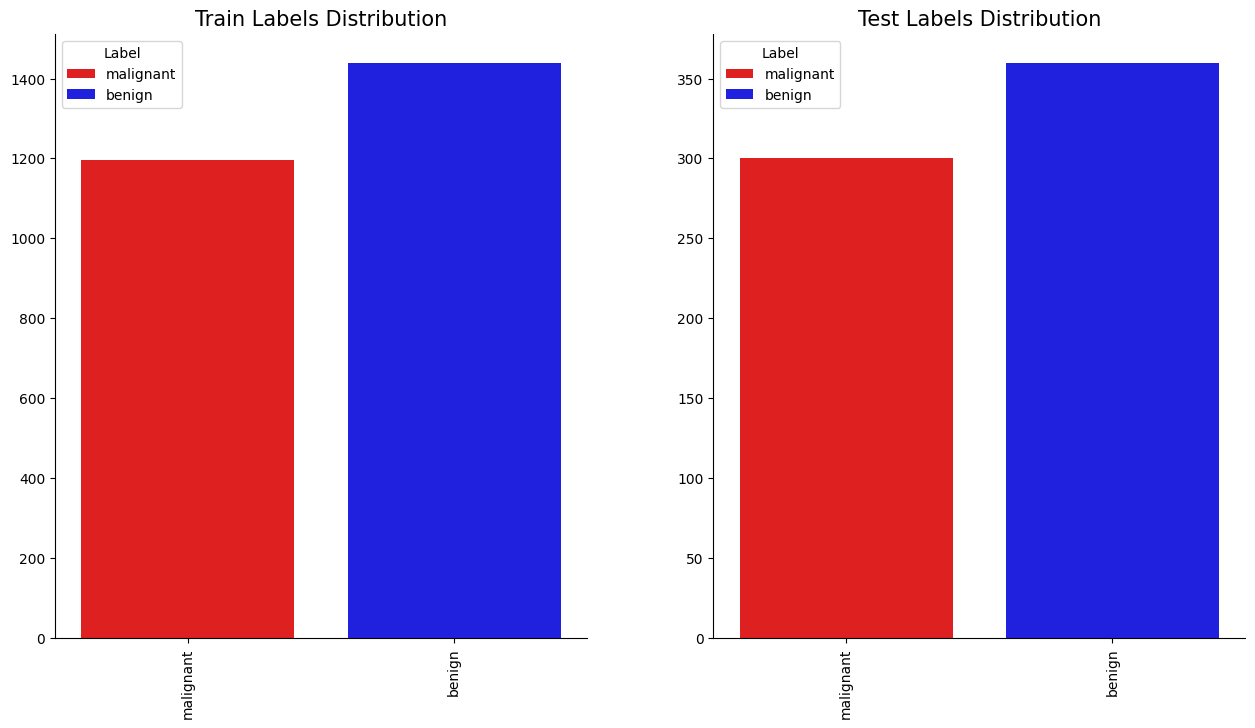

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))  # Changed to 1 row and 2 columns

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# Create a dictionary to map categories to colors
color_mapping = {'malignant': 'red', 'benign': 'blue'}

# Plot Train Labels Distribution
ax1.set_title('Train Labels Distribution', fontsize=15)

# Plot each category with its specific color
for category, color in color_mapping.items():
    # Filter the data for the category
    cat_data = train_class_count.get(category, 0)
    sns.barplot(x=[category], y=[cat_data], color=color, ax=ax1, label=category)

# Plot Test Labels Distribution
ax2.set_title('Test Labels Distribution', fontsize=15)

# Plot each category with its specific color
for category, color in color_mapping.items():
    # Filter the data for the category
    cat_data = test_class_count.get(category, 0)
    sns.barplot(x=[category], y=[cat_data], color=color, ax=ax2, label=category)

# To prevent the labels from overlapping with the plots
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=90)

# Add legend
ax1.legend(title="Label")
ax2.legend(title="Label")

sns.despine()

plt.show()

E0000 00:00:1780776395.951936    8695 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780776395.952334    8838 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780776395.982939    8695 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-7.625937e-09..1.0].
Clipping input data to the valid

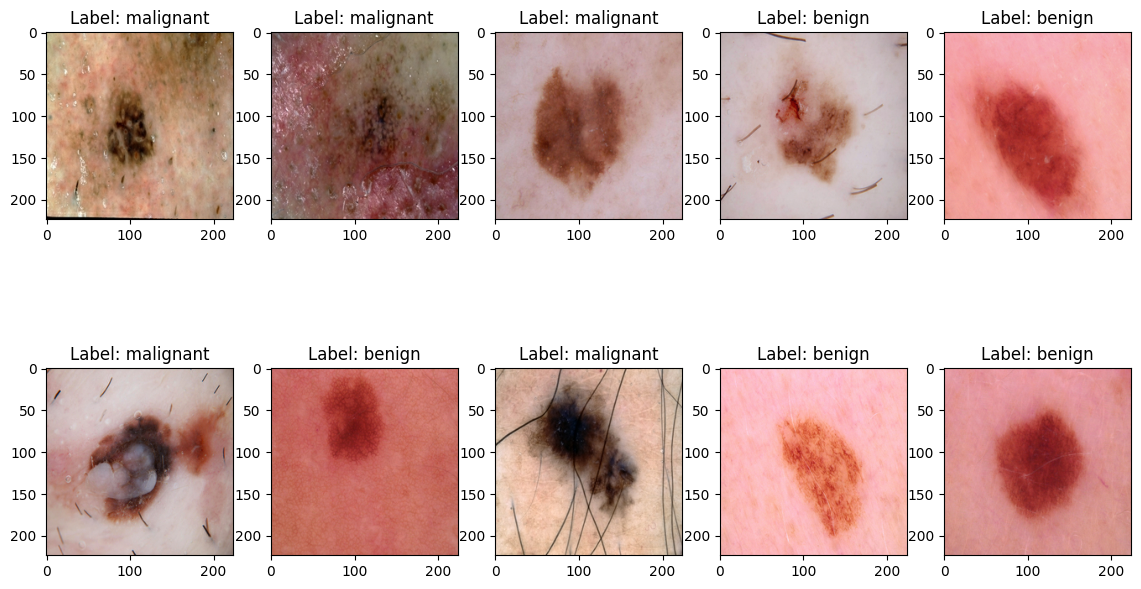

In [8]:
# View sample training images from both the classes
def load_image(image_path):

    # Read and decode an image file to a uint8 tensor
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=3)

    # Resize image
    image = tf.image.resize(image, [224, 224],
                            method = tf.image.ResizeMethod.LANCZOS3)

    # Convert image dtype to float32 and NORMALIZE!!!
    image = tf.cast(image, tf.float32)/255.

    # Return image
    return image

idx = random.sample(train_df.index.to_list(), 10)
fig = plt.figure(figsize=(14,8))

for id, _ in enumerate(idx):

    plt.subplot(2, 5, id+1)
    plt.title(f'Label: {train_df.label[_]}')
    plt.imshow(load_image(train_df.image_path[_]))

## Pre-processing data

This code performes few pre-processing steps on training & testing data like:
- split training into train-validation split
- add custom augmengtation layer(can be replaced with ImageDataGenerator) - here data is preety much balanced already so no need to do higher augmentation, only randomflip & randomzoom is performed.
- prepare tensor dataset and batches using tensorfloe.data.Dataset to fit in the training data


In [9]:
# Split the training data into train-validation set
train_idx, val_ind, _, _ = train_test_split(train_df.index, train_df.label_encoded, test_size = 0.20,
                                            stratify = train_df.label_encoded, random_state = 42)

# Get training and validation data
train_new_df = train_df.iloc[train_idx].reset_index(drop=True)
val_df = train_df.iloc[val_ind].reset_index(drop=True)

# View shapes
print(f"training size: {train_new_df.shape}, validation size: {val_df.shape}")

training size: (2109, 3), validation size: (528, 3)


In [10]:
# Check class balance in both trainng and validation set
train_class_count = train_new_df['label'].value_counts()
val_class_count = val_df['label'].value_counts()

print(f"train_class_count: {train_class_count}")
print(f"test_class_count: {val_class_count}")

train_class_count: label
benign       1152
malignant     957
Name: count, dtype: int64
test_class_count: label
benign       288
malignant    240
Name: count, dtype: int64


In [11]:
# Build custome augmentation layer
augmentation_layer = Sequential([
    layers.RandomFlip(mode='horizontal_and_vertical', seed = 42),
    layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1), seed = 42),
], name='augmentation_layer')

In [12]:
# Define function to build tensor batched dataset
def pre_processing(orig_df, augmentation = False):

    # Get image paths and labels from DataFrame
    image_paths = orig_df.image_path
    image_labels = tf.one_hot(orig_df.label_encoded, depth = 2).numpy()

    # create tensor dataset from original data
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, image_labels))

    # apply augmentation layer to the data
    if augmentation:
          dataset = dataset.map(lambda x, y: (augmentation_layer(load_image(x)), y), num_parallel_calls = tf.data.AUTOTUNE)
    else:
          dataset = dataset.map(lambda x, y: (load_image(x), y), num_parallel_calls = tf.data.AUTOTUNE)

    # apply batching
    dataset = dataset.batch(32)

    return dataset

In [13]:
# Generate tensor datasets for train, validation(no augmentation) and test(no augmentation)
train_dataset = pre_processing(train_new_df, augmentation = True)

val_dataset = pre_processing(val_df)

test_dataset = pre_processing(test_df)

In [14]:
# Define early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True)

In [15]:
EPOCHS = 1

# Feature-level Fusion (Xception + ResNet50 + VGG)

- Xception foca em convoluções separáveis na profundidade;
- ResNet mitiga o sumiço do gradiente com conexões residuais;
- VGG foca em texturas locais com filtros menores.

In [ ]:
# 1. Definir a entrada única para as 3 redes
input_shape = (224, 224, 3)
shared_input = layers.Input(shape=input_shape, dtype=tf.float32, name='shared_input_image')

# 2. Carregar e congelar as bases (sem pooling na importação para manter o padrão)
base_xception = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=input_shape)
base_resnet = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_vgg16 = keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

base_xception.trainable = False
base_resnet.trainable = False
base_vgg16.trainable = False

# 3. Passar a entrada por cada rede (lembrando do training=False para BatchNorm)
x_xc = base_xception(shared_input, training=False)
x_rn = base_resnet(shared_input, training=False)
x_vg = base_vgg16(shared_input, training=False)

feat_xc = layers.GlobalAveragePooling2D(name='xc_gap')(x_xc)
feat_rn = layers.GlobalAveragePooling2D(name='rn_gap')(x_rn)
feat_vg = layers.GlobalAveragePooling2D(name='vg_gap')(x_vg)

# Opção A: Concatenar as saídas globais de cada rede
# combined_features = layers.concatenate([feat_xc, feat_rn, feat_vg], name='fusion_concatenate')

# Opção B: Fusão ponderada
proj_xc = layers.Dense(512, activation='relu', name='weight_xc')(feat_xc)
proj_rn = layers.Dense(512, activation='relu', name='weight_rn')(feat_rn)
proj_vg = layers.Dense(512, activation='relu', name='weight_vg')(feat_vg)
combined_features = layers.add([proj_xc, proj_rn, proj_vg], name='weighted_fusion_add')

# 6. Camadas Densas Adaptativas do Topo (Baseado no seu design)
x = layers.Dropout(0.3)(combined_features)  # Dropout logo após a fusão evita overfitting
x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dense(256, activation='relu')(x)

outputs = layers.Dense(2, activation='softmax', name='output_layer')(x)

# 8. Construir e Compilar o Modelo Ensemble
ensemble_model = Model(inputs=shared_input, outputs=outputs, name='Ensemble_Fusion_Model')

tf.random.set_seed(42)

ensemble_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo da estrutura
ensemble_model.summary()

In [18]:
ensemble_training = ensemble_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    validation_steps=int(len(val_dataset)),
    callbacks=[early_stopping]
)

: 

# Feature-level Fusion (Xception + ResNet50 + EfficientNet)

In [16]:
# 1. Definir a entrada única para as 3 redes
input_shape = (224, 224, 3)
shared_input = layers.Input(shape=input_shape, dtype=tf.float32, name='shared_input_image')

# 2. Carregar e congelar as bases (sem pooling na importação para manter o padrão)
base_xception = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=input_shape)
base_resnet = keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_efficientnet = keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)

base_xception.trainable = False
base_resnet.trainable = False
base_efficientnet.trainable = False

# 3. Passar a entrada por cada rede (lembrando do training=False para BatchNorm)
x_xc = base_xception(shared_input, training=False)
x_rn = base_resnet(shared_input, training=False)
x_fn = base_efficientnet(shared_input, training=False)

feat_xc = layers.GlobalAveragePooling2D(name='xc_gap')(x_xc)
feat_rn = layers.GlobalAveragePooling2D(name='rn_gap')(x_rn)
feat_fn = layers.GlobalAveragePooling2D(name='fn_gap')(x_fn)

# Opção A: Concatenar as saídas globais de cada rede
# combined_features = layers.concatenate([feat_xc, feat_rn, feat_fn], name='fusion_concatenate')

# Opção B: Fusão ponderada
proj_xc = layers.Dense(512, activation='relu', name='weight_xc')(feat_xc)
proj_rn = layers.Dense(512, activation='relu', name='weight_rn')(feat_rn)
proj_fn = layers.Dense(512, activation='relu', name='weight_fn')(feat_fn)
combined_features = layers.add([proj_xc, proj_rn, proj_fn], name='weighted_fusion_add')

# 6. Camadas Densas Adaptativas do Topo (Baseado no seu design)
x = layers.Dropout(0.3)(combined_features)  # Dropout logo após a fusão evita overfitting
x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dense(256, activation='relu')(x)

outputs = layers.Dense(2, activation='softmax', name='output_layer')(x)

# 8. Construir e Compilar o Modelo Ensemble
ensemble_model = Model(inputs=shared_input, outputs=outputs, name='Ensemble_Fusion_Model')

tf.random.set_seed(42)

ensemble_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo da estrutura
ensemble_model.summary()

Model: "Ensemble_Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ shared_input_image  │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception            │ (None, 7, 7,      │ 20,861,480 │ shared_input_ima… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ shared_input_ima… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ shared_input_ima… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xc_gap              │ (None, 2048)      │          0 │ xception[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rn_gap              │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fn_gap              │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weight_xc (Dense)   │ (None, 512)       │  1,049,088 │ xc_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weight_rn (Dense)   │ (None, 512)       │  1,049,088 │ rn_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weight_fn (Dense)   │ (None, 512)       │    655,872 │ fn_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_fusion_add │ (None, 512)       │          0 │ weight_xc[0][0],  │
│ (Add)               │                   │            │ weight_rn[0][0],  │
│                     │                   │            │ weight_fn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ weighted_fusion_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    262,656 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 2)         │        514 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,647,309 (197.02 MB)

 Trainable params: 3,148,546 (12.01 MB)

 Non-trainable params: 48,498,763 (185.01 MB)

In [17]:
ensemble_training = ensemble_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    validation_steps=int(len(val_dataset)),
    callbacks=[early_stopping]
)

: 

# Feature-level Fusion

In [17]:
# 1. Definir a entrada única para as 3 redes
input_shape = (224, 224, 3)
shared_input = layers.Input(shape=input_shape, dtype=tf.float32, name='shared_input_image')

# 2. Carregar e congelar as bases (sem pooling na importação para manter o padrão)
base_xception = keras.applications.Xception(weights='imagenet', include_top=False, input_shape=input_shape)
base_efficientnet = keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)

base_xception.trainable = False
base_efficientnet.trainable = False

# 3. Passar a entrada por cada rede (lembrando do training=False para BatchNorm)
x_xc = base_xception(shared_input, training=False)
x_fn = base_efficientnet(shared_input, training=False)

feat_xc = layers.GlobalAveragePooling2D(name='xc_gap')(x_xc)
feat_fn = layers.GlobalAveragePooling2D(name='fn_gap')(x_fn)

# Opção A: Concatenar as saídas globais de cada rede
combined_features = layers.concatenate([feat_xc, feat_fn], name='fusion_concatenate')

# 6. Camadas Densas Adaptativas do Topo (Baseado no seu design)
x = layers.Dropout(0.3)(combined_features)  # Dropout logo após a fusão evita overfitting
x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dense(256, activation='relu')(x)

outputs = layers.Dense(2, activation='softmax', name='output_layer')(x)

# 8. Construir e Compilar o Modelo Ensemble
ensemble_model = Model(inputs=shared_input, outputs=outputs, name='Ensemble_Fusion_Model')

tf.random.set_seed(42)

ensemble_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo da estrutura
ensemble_model.summary()

Model: "Ensemble_Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ shared_input_image  │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception            │ (None, 7, 7,      │ 20,861,480 │ shared_input_ima… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ shared_input_ima… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xc_gap              │ (None, 2048)      │          0 │ xception[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fn_gap              │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concatenate  │ (None, 3328)      │          0 │ xc_gap[0][0],     │
│ (Concatenate)       │                   │            │ fn_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 3328)      │          0 │ fusion_concatena… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,704,448 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 2)         │        514 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,747,341 (102.03 MB)

 Trainable params: 1,836,290 (7.00 MB)

 Non-trainable params: 24,911,051 (95.03 MB)

In [18]:
ensemble_training = ensemble_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    validation_steps=int(len(val_dataset)),
    callbacks=[early_stopping]
)

: 